# M-CaStLe vs Naive M-CaStLe — Benchmark Comparison

This notebook benchmarks **M-CaStLe** against **Naive M-CaStLe** across 30 replicates of randomly generated 4-variable, 4×4 grid spatiotemporal data.

**Setup:**
- 4 variables, 4×4 toroidal grid, T=500 time steps
- Link density = 0.15 (≈22 links out of 144 possible)
- Minimum coefficient magnitude = 0.1
- `pc_alpha = graph_p_threshold = 0.1` for both methods
- 30 replicates (different random seeds → different causal structures)

**Caching:** Results are stored in `../data/replicates/`, `../data/mcastle_results/`, and `../data/naive_results/`. On the **first run**, data and algorithm outputs are generated automatically (this may take several minutes). Subsequent runs load from cache.

**Plots:**
1. Box plots — full stencil F1 and reaction graph F1 side by side
2. Scatter plot — M-CaStLe F1 vs Naive M-CaStLe F1 per replicate (stencil and reaction graph)
3. Precision / recall breakdown

**Key question:** Does M-CaStLe's joint inference outperform the naive per-variable-then-aggregate approach, and by how much?

## Setup

In [1]:
import sys, os, glob, warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from tigramite.independence_tests.parcorr import ParCorr

sys.path.append('../src')
import spatiotemporal_SCM_data_generator as dg
import mcastle_utils as mcastle
import causal_graph_metrics as gm
from naive_mcastle_utils import naive_mv_CaStLe_PC

## Parameters

In [2]:
# ── Experiment parameters ───────────────────────────────────────────────────
N_VARS    = 4
GRID_SIZE = 4
DENSITY   = 0.15
MIN_VAL   = 0.1
N_REP     = 30
T         = 500
PC_ALPHA  = 0.1
PVAL_THR  = 0.1

# ── Cache directories ───────────────────────────────────────────────────────
TAG = f"n{N_VARS}_g{GRID_SIZE}_d{int(DENSITY*100):03d}"

DATA_DIR    = os.path.join('..', 'data', 'replicates')
MC_DIR      = os.path.join('..', 'data', 'mcastle_results')
NAIVE_DIR   = os.path.join('..', 'data', 'naive_results')

for d in [DATA_DIR, MC_DIR, NAIVE_DIR]:
    os.makedirs(d, exist_ok=True)

def rep_path(base, tag, rep_idx, ext='.npz'):
    return os.path.join(base, f"{tag}_rep{rep_idx:02d}{ext}")

print(f"Tag: {TAG}")
print(f"Data dir   : {DATA_DIR}")
print(f"M-CaStLe   : {MC_DIR}")
print(f"Naive      : {NAIVE_DIR}")

Tag: n4_g4_d015
Data dir   : ../data/replicates
M-CaStLe   : ../data/mcastle_results
Naive      : ../data/naive_results


## Data Generation / Loading

Each replicate uses `random_seed = rep_idx` so the same index always produces the same dataset. If the cached file already exists it is loaded rather than regenerated.

In [3]:
data_paths = [rep_path(DATA_DIR, TAG, i) for i in range(N_REP)]
missing    = [i for i, p in enumerate(data_paths) if not os.path.exists(p)]

if missing:
    print(f"Generating {len(missing)} missing replicate(s)...")
    for i in missing:
        coefs, data = dg.generate_dataset(
            T=T,
            grid_size=GRID_SIZE,
            num_variables=N_VARS,
            dependence_density=DENSITY,
            coefficient_min_value_threshold=MIN_VAL,
            return_coefs=True,
            random_seed=i,
            verbose=0,
        )
        np.savez(data_paths[i], coefs=coefs, data=data)
        print(f"  rep {i:02d}: {int(np.sum(coefs != 0))} links saved")
else:
    print(f"All {N_REP} replicates cached — loading.")

# Quick sanity-check on one replicate
sample = np.load(data_paths[0], allow_pickle=True)
print(f"\nSample rep 00: coefs {sample['coefs'].shape}, data {sample['data'].shape}")

All 30 replicates cached — loading.

Sample rep 00: coefs (4, 3, 3), data (4, 4, 4, 500)


## Run M-CaStLe on All Replicates

Results are cached per replicate. Only missing runs are executed.

In [4]:
mc_paths = [rep_path(MC_DIR, TAG, i) for i in range(N_REP)]
missing_mc = [i for i, p in enumerate(mc_paths) if not os.path.exists(p)]

if missing_mc:
    print(f"Running M-CaStLe on {len(missing_mc)} replicate(s)...")
    for i in missing_mc:
        rep = np.load(data_paths[i], allow_pickle=True)
        ci  = ParCorr(significance='analytic')
        res = mcastle.mv_CaStLe_PC(
            data=rep['data'],
            cond_ind_test=ci,
            pc_alpha=PC_ALPHA,
            graph_p_threshold=PVAL_THR,
            min_tau=1,
            rows_inverted=True,
            cd_function='run_pcalg',
            fdr_method='bh',
            dependencies_wrap=True,
            allow_center_directed_links=True,
            verbose=0,
        )
        np.savez(mc_paths[i],
                 graph=res['graph'],
                 val_matrix=res['val_matrix'])
        print(f"  rep {i:02d} done")
else:
    print(f"All {N_REP} M-CaStLe results cached.")

All 30 M-CaStLe results cached.


## Run Naive M-CaStLe on All Replicates

In [5]:
naive_paths  = [rep_path(NAIVE_DIR, TAG, i) for i in range(N_REP)]
missing_naive = [i for i, p in enumerate(naive_paths) if not os.path.exists(p)]

if missing_naive:
    print(f"Running Naive M-CaStLe on {len(missing_naive)} replicate(s)...")
    for i in missing_naive:
        rep = np.load(data_paths[i], allow_pickle=True)
        ci  = ParCorr(significance='analytic')
        res = naive_mv_CaStLe_PC(
            data=rep['data'],
            cond_ind_test=ci,
            pc_alpha=PC_ALPHA,
            graph_p_threshold=PVAL_THR,
            min_tau=1,
            rows_inverted=True,
            cd_function='run_pcalg',
            fdr_method='bh',
            dependencies_wrap=True,
            allow_center_directed_links=True,
            verbose=0,
        )
        np.savez(naive_paths[i],
                 graph=res['graph'],
                 val_matrix=res['val_matrix'])
        print(f"  rep {i:02d} done")
else:
    print(f"All {N_REP} Naive M-CaStLe results cached.")

All 30 Naive M-CaStLe results cached.


## Compute F1 Scores

In [6]:
mc_f1_s    = []   # M-CaStLe  — full stencil F1
mc_f1_rx   = []   # M-CaStLe  — reaction graph F1
mc_prec_s  = []; mc_rec_s  = []
mc_prec_rx = []; mc_rec_rx = []

nv_f1_s    = []   # Naive M-CaStLe — full stencil F1
nv_f1_rx   = []   # Naive M-CaStLe — reaction graph F1
nv_prec_s  = []; nv_rec_s  = []
nv_prec_rx = []; nv_rec_rx = []

for i in range(N_REP):
    rep       = np.load(data_paths[i], allow_pickle=True)
    true_s, true_v = mcastle.get_stencil_graph_from_coefficients(rep['coefs'])
    true_rx, true_rx_v, _, _ = mcastle.analyze_stencil_graphs(true_s, true_v)

    for (paths, f1_s, f1_rx, ps, rs, prx, rrx) in [
        (mc_paths,    mc_f1_s,  mc_f1_rx,  mc_prec_s,  mc_rec_s,  mc_prec_rx,  mc_rec_rx),
        (naive_paths, nv_f1_s,  nv_f1_rx,  nv_prec_s,  nv_rec_s,  nv_prec_rx,  nv_rec_rx),
    ]:
        res = np.load(paths[i], allow_pickle=True)
        disc_s = res['graph']
        disc_rx, disc_rx_v, _, _ = mcastle.analyze_stencil_graphs(disc_s, res['val_matrix'])

        TP, FP, FN, TN = gm.get_confusion_matrix(true_s, disc_s)
        F1, P, R, *_   = gm.F1_score(TP=TP, FP=FP, FN=FN, TN=TN)
        f1_s.append(F1); ps.append(P); rs.append(R)

        TP, FP, FN, TN = gm.get_confusion_matrix(true_rx, disc_rx)
        F1, P, R, *_   = gm.F1_score(TP=TP, FP=FP, FN=FN, TN=TN)
        f1_rx.append(F1); prx.append(P); rrx.append(R)

print(f"M-CaStLe   — Stencil F1: {np.mean(mc_f1_s):.3f} ± {np.std(mc_f1_s):.3f}")
print(f"             Reaction F1: {np.mean(mc_f1_rx):.3f} ± {np.std(mc_f1_rx):.3f}")
print()
print(f"Naive M-CaStLe — Stencil F1: {np.mean(nv_f1_s):.3f} ± {np.std(nv_f1_s):.3f}")
print(f"                 Reaction F1: {np.mean(nv_f1_rx):.3f} ± {np.std(nv_f1_rx):.3f}")

M-CaStLe   — Stencil F1: 0.747 ± 0.092
             Reaction F1: 0.768 ± 0.056

Naive M-CaStLe — Stencil F1: 0.322 ± 0.091
                 Reaction F1: 0.728 ± 0.078


## Plot 1 — F1 Box Plots vs Ground Truth

Direct comparison of both methods against the ground-truth stencil and reaction graph.

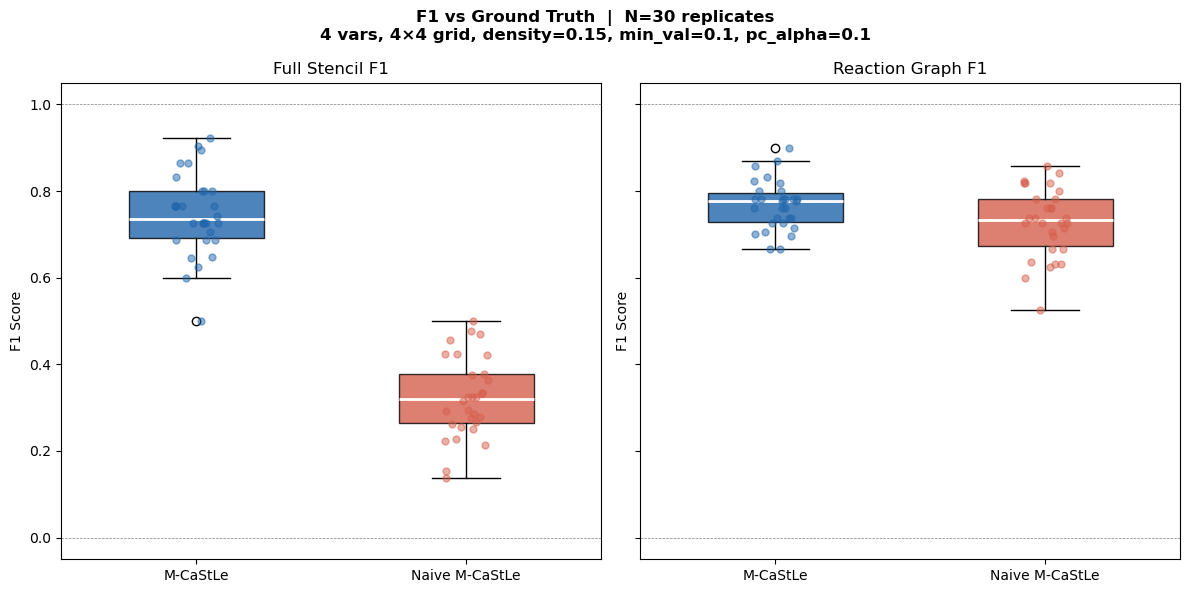

In [7]:
MC_COLOR    = '#2166ac'
NAIVE_COLOR = '#d6604d'

fig, axs = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

for ax, (mc_vals, nv_vals), metric_name in zip(
    axs,
    [(mc_f1_s, nv_f1_s), (mc_f1_rx, nv_f1_rx)],
    ['Full Stencil F1', 'Reaction Graph F1'],
):
    bp = ax.boxplot(
        [mc_vals, nv_vals],
        patch_artist=True,
        widths=0.5,
        medianprops=dict(color='white', linewidth=2),
    )
    for patch, color in zip(bp['boxes'], [MC_COLOR, NAIVE_COLOR]):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)

    # Overlay individual points with jitter
    for j, (vals, color) in enumerate([(mc_vals, MC_COLOR), (nv_vals, NAIVE_COLOR)], 1):
        jitter = np.random.default_rng(0).uniform(-0.08, 0.08, len(vals))
        ax.scatter(np.full(len(vals), j) + jitter, vals,
                   color=color, alpha=0.5, s=25, zorder=3)

    ax.set_xticks([1, 2])
    ax.set_xticklabels(['M-CaStLe', 'Naive M-CaStLe'])
    ax.set_ylabel('F1 Score')
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(metric_name)
    ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
    ax.axhline(1, color='grey', linewidth=0.5, linestyle='--')

fig.suptitle(
    f"F1 vs Ground Truth  |  N={N_REP} replicates\n"
    f"4 vars, 4×4 grid, density={DENSITY}, min_val={MIN_VAL}, pc_alpha={PC_ALPHA}",
    fontsize=12, fontweight='bold',
)
plt.tight_layout()
plt.show()

## Plot 2 — Replicate-Level Scatter: M-CaStLe vs Naive M-CaStLe

Each point is one replicate. Points above the y=x diagonal indicate Naive > M-CaStLe on that replicate; below indicates M-CaStLe > Naive.

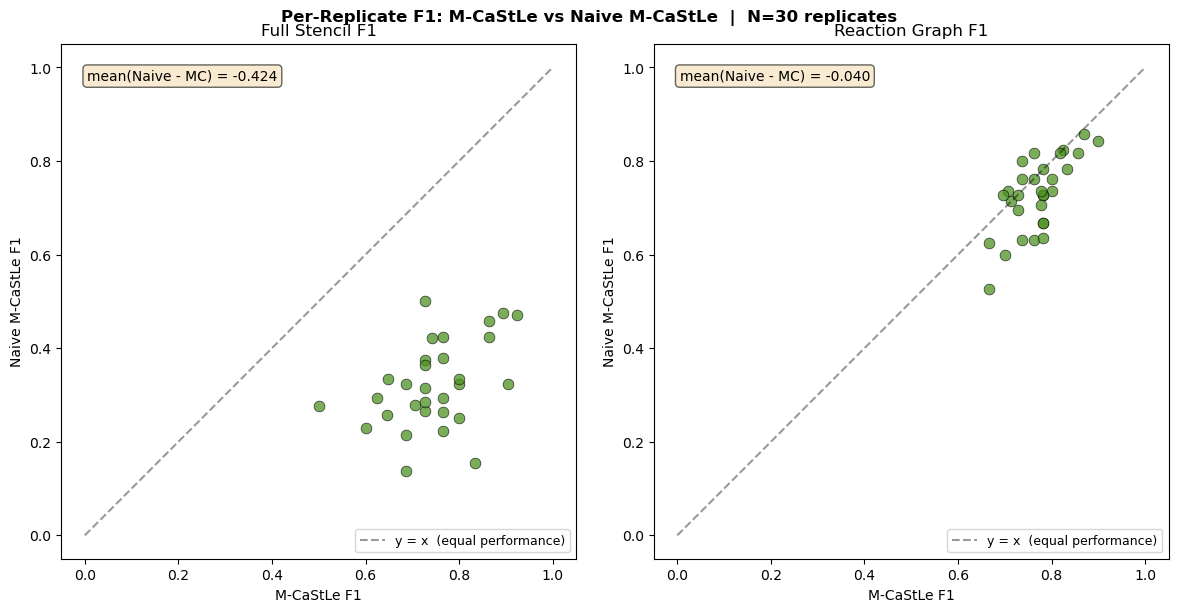

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

for ax, (mc_vals, nv_vals), metric_name in zip(
    axs,
    [(mc_f1_s, nv_f1_s), (mc_f1_rx, nv_f1_rx)],
    ['Full Stencil F1', 'Reaction Graph F1'],
):
    ax.scatter(mc_vals, nv_vals, alpha=0.75, s=60,
               color='#4d9221', edgecolors='k', linewidths=0.5)
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='y = x  (equal performance)')

    # Annotate mean delta
    delta = np.mean(nv_vals) - np.mean(mc_vals)
    sign  = '+' if delta >= 0 else ''
    ax.text(0.05, 0.93,
            f"mean(Naive - MC) = {sign}{delta:.3f}",
            transform=ax.transAxes, fontsize=10,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

    ax.set_xlabel('M-CaStLe F1')
    ax.set_ylabel('Naive M-CaStLe F1')
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(metric_name)
    ax.legend(fontsize=9)
    ax.set_aspect('equal')

fig.suptitle(
    f"Per-Replicate F1: M-CaStLe vs Naive M-CaStLe  |  N={N_REP} replicates",
    fontsize=12, fontweight='bold',
)
plt.tight_layout()
plt.show()

## Plot 3 — Precision and Recall Breakdown

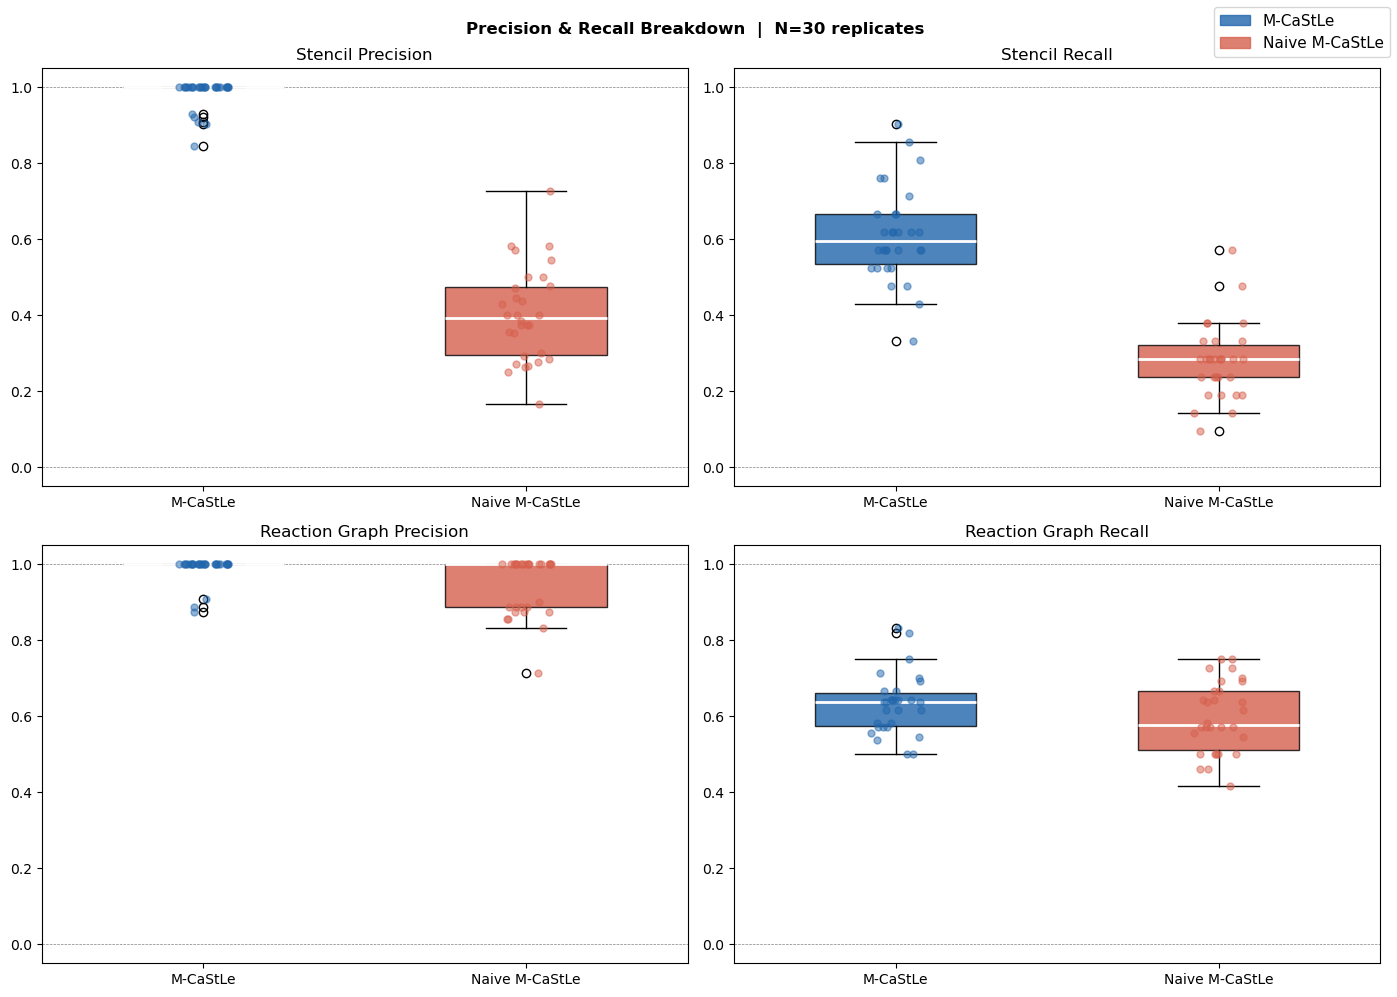

In [9]:
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

metrics_map = [
    (axs[0, 0], mc_prec_s,  nv_prec_s,  'Stencil Precision'),
    (axs[0, 1], mc_rec_s,   nv_rec_s,   'Stencil Recall'),
    (axs[1, 0], mc_prec_rx, nv_prec_rx, 'Reaction Graph Precision'),
    (axs[1, 1], mc_rec_rx,  nv_rec_rx,  'Reaction Graph Recall'),
]

for ax, mc_vals, nv_vals, title in metrics_map:
    bp = ax.boxplot(
        [mc_vals, nv_vals],
        patch_artist=True,
        widths=0.5,
        medianprops=dict(color='white', linewidth=2),
    )
    for patch, color in zip(bp['boxes'], [MC_COLOR, NAIVE_COLOR]):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    for j, (vals, color) in enumerate([(mc_vals, MC_COLOR), (nv_vals, NAIVE_COLOR)], 1):
        jitter = np.random.default_rng(1).uniform(-0.08, 0.08, len(vals))
        ax.scatter(np.full(len(vals), j) + jitter, vals,
                   color=color, alpha=0.5, s=25, zorder=3)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['M-CaStLe', 'Naive M-CaStLe'])
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(title)
    ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
    ax.axhline(1, color='grey', linewidth=0.5, linestyle='--')

mc_patch    = mpatches.Patch(color=MC_COLOR,    alpha=0.8, label='M-CaStLe')
naive_patch = mpatches.Patch(color=NAIVE_COLOR, alpha=0.8, label='Naive M-CaStLe')
fig.legend(handles=[mc_patch, naive_patch], loc='upper right', fontsize=11)

fig.suptitle(
    f"Precision & Recall Breakdown  |  N={N_REP} replicates",
    fontsize=12, fontweight='bold',
)
plt.tight_layout()
plt.show()

## Summary Table

In [10]:
import pandas as pd

rows = []
for method, f1s, f1rx, ps, rs, prx, rrx in [
    ('M-CaStLe',       mc_f1_s, mc_f1_rx, mc_prec_s, mc_rec_s, mc_prec_rx, mc_rec_rx),
    ('Naive M-CaStLe', nv_f1_s, nv_f1_rx, nv_prec_s, nv_rec_s, nv_prec_rx, nv_rec_rx),
]:
    rows.append({
        'Method':           method,
        'Stencil F1':       f"{np.mean(f1s):.3f} ± {np.std(f1s):.3f}",
        'Stencil Prec':     f"{np.mean(ps):.3f}  ± {np.std(ps):.3f}",
        'Stencil Rec':      f"{np.mean(rs):.3f}  ± {np.std(rs):.3f}",
        'Reaction F1':      f"{np.mean(f1rx):.3f} ± {np.std(f1rx):.3f}",
        'Reaction Prec':    f"{np.mean(prx):.3f}  ± {np.std(prx):.3f}",
        'Reaction Rec':     f"{np.mean(rrx):.3f}  ± {np.std(rrx):.3f}",
    })

df = pd.DataFrame(rows).set_index('Method')
print(df.to_string())
df

                   Stencil F1    Stencil Prec     Stencil Rec    Reaction F1   Reaction Prec    Reaction Rec
Method                                                                                                      
M-CaStLe        0.747 ± 0.092  0.984  ± 0.038  0.611  ± 0.121  0.768 ± 0.056  0.989  ± 0.033  0.632  ± 0.078
Naive M-CaStLe  0.322 ± 0.091  0.402  ± 0.122  0.279  ± 0.096  0.728 ± 0.078  0.945  ± 0.074  0.598  ± 0.091


,Stencil F1,Stencil Prec,Stencil Rec,Reaction F1,Reaction Prec,Reaction Rec
Method,,,,,,
M-CaStLe,0.747 ± 0.092,0.984 ± 0.038,0.611 ± 0.121,0.768 ± 0.056,0.989 ± 0.033,0.632 ± 0.078
Naive M-CaStLe,0.322 ± 0.091,0.402 ± 0.122,0.279 ± 0.096,0.728 ± 0.078,0.945 ± 0.074,0.598 ± 0.091
